<a href="https://colab.research.google.com/github/eltongaspar/python/blob/Advpl/aula14_monitoramento_modelo_aluno_Pro_Educador.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula 14 – Monitoramento e validação contínua do modelo

## Versão do aluno

### Objetivo da aula
Interpretar a confiabilidade do modelo após implantação e propor critérios de monitoramento e revalidação.

### Instruções
Complete as células indicadas ao longo da atividade e registre suas interpretações técnicas.  
Nesta aula, o foco é construir uma visão de **acompanhamento contínuo do modelo**.


## 1. Importação das bibliotecas

Importe as bibliotecas necessárias para:
- leitura e manipulação da base;
- visualização;
- pré-processamento;
- treino do classificador;
- avaliação do modelo.


In [6]:
# Complete aqui
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Leitura da base

Leia o arquivo `dados_aula14_monitoramento_modelo.csv` e exiba as primeiras linhas.


In [9]:
# Complete aqui
df = pd.read_csv('/content/drive/MyDrive/Classroom/Deep Learning Pró Educador/dados_aula14_monitoramento_modelo.csv')
df.head()

,id_registro,periodo,linha,turno,produto,temperatura_c,pressao_bar,vibracao_mm_s,tempo_resposta_s,erro_vazao_pct,leituras_invalidas,consumo_energia_kwh,falha_critica
0,MON_0001,historico_treino,Linha_A,Tarde,Solvente,43.91,3.64,2.06,2.27,5.33,2,21.89,0
1,MON_0002,historico_treino,Linha_B,Tarde,Base,46.95,4.58,2.08,3.14,2.74,0,17.40,0
2,MON_0003,historico_treino,Linha_C,Noite,Base,49.50,4.86,2.67,2.22,2.93,2,20.11,0
3,MON_0004,historico_treino,Linha_B,Tarde,Acido,39.12,4.30,1.34,3.00,0.77,3,21.59,0
4,MON_0005,historico_treino,Linha_C,Manhã,Base,57.67,3.38,1.47,1.96,3.11,5,20.35,0


## 3. Inspeção inicial da base

Verifique:
- dimensão da base;
- tipos de dados;
- valores faltantes;
- duplicatas;
- distribuição do período.


In [13]:
# Complete aqui
print('Dimensão da base:', df.shape)
print('\nTipos de dados:')
print(df.dtypes)
print('\nValores faltantes:')
print(df.isna().sum() )
print('\nDuplicatas:', df.duplicated().sum())
print('\nDistribuição do período:')
print(df['periodo'].value_counts())

Dimensão da base: (492, 13)

Tipos de dados:
id_registro             object
periodo                 object
linha                   object
turno                   object
produto                 object
temperatura_c          float64
pressao_bar            float64
vibracao_mm_s          float64
tempo_resposta_s       float64
erro_vazao_pct         float64
leituras_invalidas       int64
consumo_energia_kwh    float64
falha_critica            int64
dtype: object

Valores faltantes:
id_registro            0
periodo                0
linha                  0
turno                  0
produto                8
temperatura_c          8
pressao_bar            8
vibracao_mm_s          0
tempo_resposta_s       9
erro_vazao_pct         0
leituras_invalidas     0
consumo_energia_kwh    0
falha_critica          0
dtype: int64

Duplicatas: 12

Distribuição do período:
periodo
historico_treino            264
producao_pos_implantacao    228
Name: count, dtype: int64


**Registro do aluno:**  
- A base de dados possui 492 linhas e 13 colunas.  
- Os tipos de dados incluem `object` para identificadores e categorias, `float64` para medidas contínuas, e `int64` para contagens e a variável alvo (`falha_critica`).  
- Existem valores faltantes nas colunas 'produto' (8), 'temperatura_c' (8), 'pressao_bar' (8) e 'tempo_resposta_s' (9).  
- Foram identificadas 12 linhas duplicadas.  
- A distribuição dos dados por 'periodo' mostra 264 registros de 'historico_treino' e 228 de 'producao_pos_implantacao'.

## 4. Limpeza básica

Remova as duplicatas da base.


In [14]:
# Complete aqui
df = df.drop_duplicates().copy()
print(df.shape)

(480, 13)


## 5. Separação entre histórico e produção

Separe a base em dois conjuntos:
- `historico_treino`
- `producao_pos_implantacao`


In [15]:
# Complete aqui
df_hist = df[df['periodo'] == 'historico_treino'].copy()
df_prod = df[df['periodo'] == 'producao_pos_implantacao'].copy()

print(df_hist.shape)
print(df_prod.shape)

(260, 13)
(220, 13)


## 6. Visualização das distribuições entre histórico e produção

Compare as distribuições das principais variáveis entre os dois períodos.


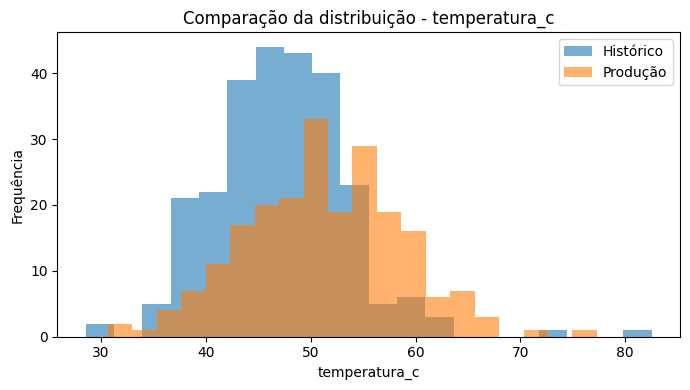

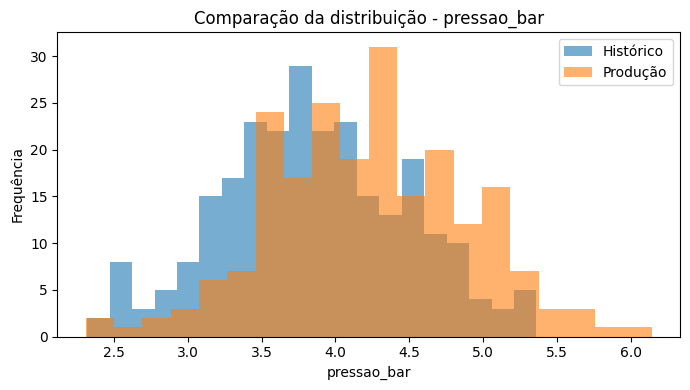

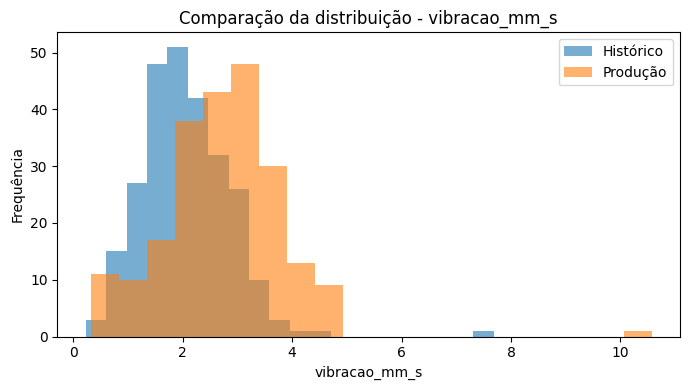

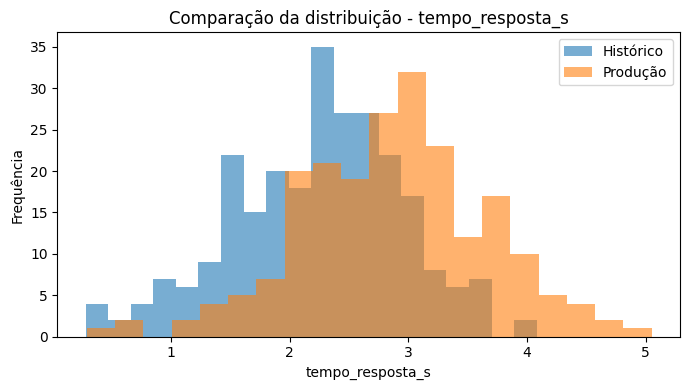

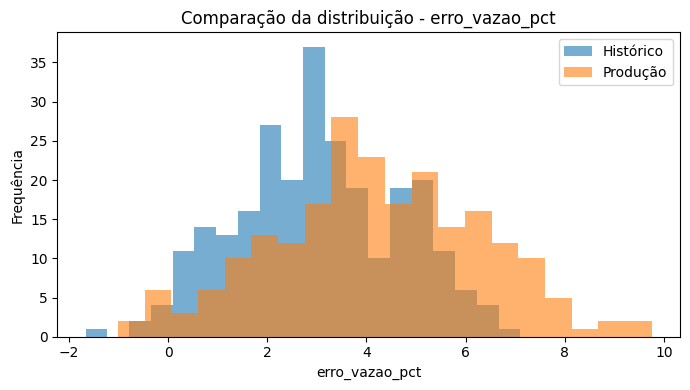

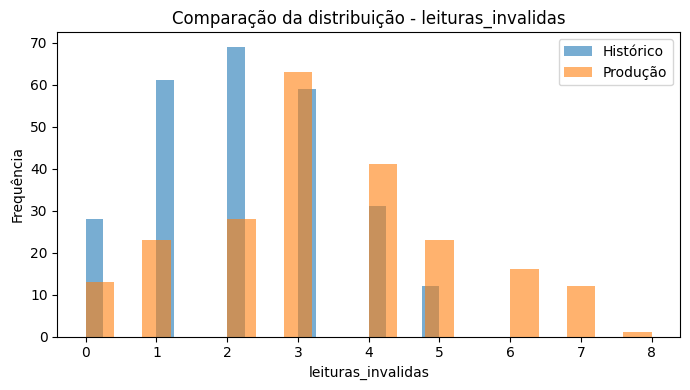

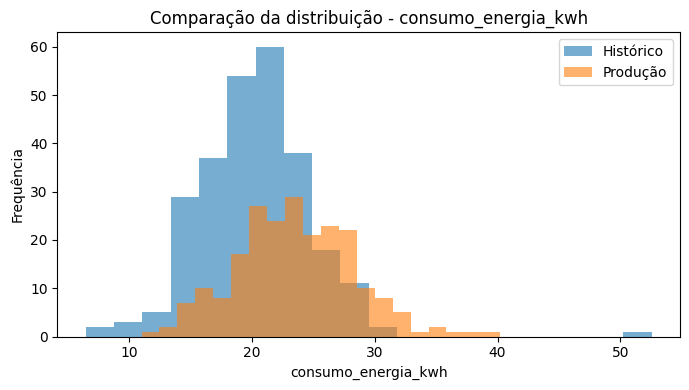

In [19]:
# Complete aqui
variaveis_monitoradas = [
    'temperatura_c', 'pressao_bar', 'vibracao_mm_s',
    'tempo_resposta_s', 'erro_vazao_pct',
    'leituras_invalidas', 'consumo_energia_kwh'
]

# Gere os gráficos aqui
for col in variaveis_monitoradas:

  plt.figure(figsize=(7, 4))
  plt.hist(df_hist[col].dropna(), bins=20, alpha=0.6, label='Histórico')
  plt.hist (df_prod[col].dropna(), bins=20, alpha=0.6, label='Produção')
  plt.title (f'Comparação da distribuição - {col}')
  plt.xlabel (col)

  plt.ylabel ('Frequência')
  plt.legend ()
  plt.tight_layout ()

  plt.show()


## 7. Estatísticas comparativas entre períodos

Monte uma tabela com médias e desvios das variáveis monitoradas.


In [20]:
# Complete aqui
comparacao_stats = pd.DataFrame({
    'media_historico': df_hist[variaveis_monitoradas].mean(),
    'media_producao': df_prod[variaveis_monitoradas].mean(),
    'desvio_historico': df_hist[variaveis_monitoradas].mean(),
    'desvio_producao': df_prod[variaveis_monitoradas].mean()
}).round(3)

comparacao_stats

,media_historico,media_producao,desvio_historico,desvio_producao
temperatura_c,47.265,51.273,47.265,51.273
pressao_bar,3.849,4.232,3.849,4.232
vibracao_mm_s,2.071,2.757,2.071,2.757
tempo_resposta_s,2.229,2.871,2.229,2.871
erro_vazao_pct,3.037,4.194,3.037,4.194
leituras_invalidas,2.154,3.341,2.154,3.341
consumo_energia_kwh,20.208,23.515,20.208,23.515


## 8. Interpretação de data drift

Explique, com suas palavras:
- o que é data drift;
- quais sinais de data drift aparecem nesta base.


**Resposta do aluno:**  
- **Conceito:** Data drift refere-se à mudança nas propriedades estatísticas dos dados de entrada (variáveis preditoras) de um modelo de machine learning ao longo do tempo. Quando o modelo é treinado em dados com uma distribuição e depois encontra dados em produção com uma distribuição diferente, seu desempenho pode se degradar.  
- **Sinais observados:** Nesta base, observamos sinais claros de data drift nas seguintes variáveis monitoradas, conforme as estatísticas comparativas (`comparacao_stats`) e os gráficos de distribuição (histogramas):  
    - **`temperatura_c`**: A média e a distribuição na produção são notavelmente mais altas do que no histórico.  
    - **`pressao_bar`**: Similar à temperatura, a pressão média e sua distribuição mostram um aumento no período de produção.  
    - **`vibracao_mm_s`**: A distribuição da vibração também se deslocou para valores mais altos na produção.  
    - **`tempo_resposta_s`**: Há um aumento na média e um deslocamento da distribuição para tempos de resposta maiores no ambiente de produção.  
    - **`erro_vazao_pct`**: O percentual de erro de vazão exibe médias e distribuições mais elevadas em produção.  
    - **`leituras_invalidas`**: O número de leituras inválidas também aumentou, com uma distribuição diferente na produção.  
    - **`consumo_energia_kwh`**: O consumo de energia é consistentemente maior na produção em comparação com o histórico.  
Esses deslocamentos nas médias e distribuições das variáveis indicam que as características dos dados de entrada que o modelo está recebendo em produção são diferentes daquelas em que foi treinado, o que pode impactar seu desempenho.

## 9. Treino do modelo de referência no histórico

Treine um modelo usando apenas a base histórica.


In [25]:
# Complete aqui
X_hist = df_hist.drop(columns=['id_registro', 'periodo', 'falha_critica'])
y_hist = df_hist['falha_critica']

X_prod = df_prod.drop(columns=['id_registro', 'periodo', 'falha_critica'])
y_prod = df_prod['falha_critica']

In [27]:
# Complete aqui
colunas_numericas = X_hist.select_dtypes(include=['int64', 'float64']).columns.tolist()
colunas_categoricas = X_hist.select_dtypes(include=['object']).columns.tolist()

transformador_numerico = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

transformador_categorico = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessador = ColumnTransformer(transformers=[
    ('num', transformador_numerico, colunas_numericas),
    ('cat', transformador_categorico, colunas_categoricas)
])

modelo = Pipeline(steps=[
    ('preprocessador', preprocessador),
    ('modelo', LogisticRegression(max_iter=1000))
])

modelo.fit(X_hist, y_hist)
print('Modelo treinado com base histórica.')

Modelo treinado com base histórica.


## 10. Avaliação do modelo no histórico e na produção

Avalie o mesmo modelo nos dois períodos.


In [28]:
# Complete aqui
pred_hist = modelo.predict(X_hist)
pred_prod = modelo.predict(X_prod)

proba_hist = modelo.predict_proba(X_hist)[:, 1]
proba_prod = modelo.predict_proba(X_prod)[:, 1]

In [32]:
# Complete aqui
def calcular_metricas_classificacao(y_real, y_pred, y_prob):
    return {
        'Acurácia': accuracy_score(y_real, y_pred),
        'Precisão': precision_score(y_real, y_pred, zero_division=0),
        'Recall': recall_score(y_real, y_pred, zero_division=0),
        'F1-score': f1_score(y_real, y_pred, zero_division=0),
        'AUC': roc_auc_score(y_real, y_prob) # Corrigido: Usar y_prob em vez de y_prod
    }

metricas_monitoramento = pd.DataFrame([
    {'Periodo': 'Histórico', **calcular_metricas_classificacao(y_hist, pred_hist, proba_hist)},
    {'Periodo': 'Produção', **calcular_metricas_classificacao(y_prod, pred_prod, proba_prod)}
]).round(4)

metricas_monitoramento

,Periodo,Acurácia,Precisão,Recall,F1-score,AUC
0,Histórico,0.8846,0.7000,0.5,0.5833,0.9392
1,Produção,0.5591,0.3356,1.0,0.5026,0.9583


## 11. Visualização da degradação de desempenho

Crie gráficos para comparar o desempenho do modelo entre histórico e produção.


In [33]:
# Complete aqui
metricas_plot = metricas_monitoramento.set_index('Periodo')

In [34]:
# Gere os gráficos aqui para Acurácia, Precisão, Recall, F1-score e AUC

## 12. Matrizes de confusão por período

Calcule as matrizes de confusão para histórico e produção.


In [35]:
# Complete aqui
cm_hist = confusion_matrix(y_hist, pred_hist)
cm_prod = confusion_matrix(y_prod, pred_prod)

print(cm_hist)
print(cm_prod)

[[209   9]
 [ 21  21]]
[[74 97]
 [ 0 49]]


## 13. Interpretação de concept drift

Explique, com suas palavras:
- o que é concept drift;
- em que ele difere do data drift;
- por que ele pode prejudicar o modelo em produção.


**Resposta do aluno:**  
- **Concept drift**: Refere-se à mudança na relação entre as variáveis de entrada (preditoras) e a variável de saída (alvo) de um modelo. Ou seja, a própria definição do conceito que o modelo tenta aprender muda ao longo do tempo. Por exemplo, o comportamento que antes significava 'falha crítica' pode mudar devido a novas condições operacionais, atualizações de software, etc.  
- **Diferença para data drift**: Enquanto o *data drift* é uma mudança nas características estatísticas dos dados de entrada (distribuição das features), o *concept drift* é uma mudança na própria função alvo que o modelo está tentando prever. O data drift pode acontecer sem concept drift (ex: sensores mais precisos mudam a distribuição dos dados de entrada, mas a relação com a falha crítica permanece a mesma), e vice-versa. No entanto, muitas vezes, eles ocorrem juntos.  
- **Impacto no modelo**: O concept drift prejudica o modelo em produção porque o modelo foi treinado para uma relação X-Y que não é mais válida. Mesmo que os dados de entrada (X) sejam similares aos de treino, a lógica interna do modelo para prever Y está desatualizada. Isso leva a previsões incorretas, diminuição drástica da acurácia, precisão, recall e F1-score, e pode resultar em decisões de negócios erradas ou falhas na detecção de eventos importantes (como falhas críticas), mesmo que o modelo continue recebendo dados 'válidos' em termos de formato e distribuição das features.

## 14. Indicadores de performance pós-implantação

Monte uma tabela com indicadores relacionados a:
- taxa de falsos positivos;
- taxa de falsos negativos;
- outras métricas do modelo.


In [37]:
# Complete aqui
tn_h, fp_h, fn_h, tp_h = cm_hist.ravel()
tn_p, fp_p, fn_p, tp_p = cm_prod.ravel()

indicadores = pd.DataFrame({
    'Indicador': [
        'Taxa de falsos positivos',
        'Taxa de falsos negativos'
    ],
    'Histórico': [
        fp_h / (fp_h + tn_h) if (fp_h + tn_h) > 0 else 0,
        fn_h / (fn_h + tp_h) if (fn_h + tp_h) > 0 else 0,

    ],
    'Produção': [
        fp_p / (fp_p + tn_p) if (fp_p + tn_p) > 0 else 0,
        fn_p / (fn_p + tp_p) if (fn_p + tp_p) > 0 else 0,

    ]
}).round(4)

indicadores

,Indicador,Histórico,Produção
0,Taxa de falsos positivos,0.0413,0.5673
1,Taxa de falsos negativos,0.5000,0.0000


## 15. Proposta de monitoramento contínuo

Monte um plano simples com:
- o que monitorar;
- periodicidade;
- objetivo.


In [38]:
# Complete aqui
plano_monitoramento = pd.DataFrame({
    'Elemento': [
        'Métricas do Mpdelo',
        'Distribuição das Variáveis',
        'Falsos Negativos',
        'Falsos Positivos',
        'Revisão do Modelo'
    ],
    'Periodicidade sugerida': [
        'Semana 1',
        'Semana 1',
        'Diária',
        'Diária',
        'Mensal ou por Gatilho'
    ],
    'Objetivo': [
        'Verificar degradação geral',
        'Identificar Data Drift',
        'Evitar falhas críticas não detectadas',
        'Controlar alarmes indevidos',
        'Revalidar ou re-treinar'
    ]
})

plano_monitoramento

,Elemento,Periodicidade sugerida,Objetivo
0,Métricas do Mpdelo,Semana 1,Verificar degradação geral
1,Distribuição das Variáveis,Semana 1,Identificar Data Drift
2,Falsos Negativos,Diária,Evitar falhas críticas não detectadas
3,Falsos Positivos,Diária,Controlar alarmes indevidos
4,Revisão do Modelo,Mensal ou por Gatilho,Revalidar ou re-treinar


## 16. Critérios para revalidação periódica

Escreva critérios objetivos para decidir quando o modelo deve ser revalidado ou re-treinado.


**Resposta do aluno:**  
- **Degradação de Métricas Chave:** O modelo deve ser revalidado ou re-treinado se qualquer uma das métricas chave (Acurácia, Precisão, Recall, F1-score, AUC) cair abaixo de um limite pré-definido (e.g., 5% a 10% de queda em relação ao desempenho histórico) por um período consecutivo (e.g., 3 dias seguidos ou uma semana). Especial atenção deve ser dada ao Recall (para não perder falhas críticas) e à Precisão (para não gerar alarmes falsos excessivos).  
- **Data Drift Significativo:** Se as distribuições das variáveis monitoradas (ex: `temperatura_c`, `pressao_bar`, `consumo_energia_kwh`) apresentarem um desvio estatisticamente significativo do padrão histórico (e.g., p-valor < 0.05 em testes de KS ou de Shapiro-Wilk para comparação de distribuições) ou uma mudança persistente nas médias/desvios padrão que exceda um limiar de tolerância.  
- **Aumento na Taxa de Falsos Negativos ou Falsos Positivos:** Um aumento substancial e contínuo (e.g., acima de 10% do valor de referência histórico) na taxa de falsos negativos (modelos não detectando falhas críticas) ou falsos positivos (modelos gerando alarmes desnecessários), que indique um impacto negativo na operação. Além disso, se a taxa de falsos negativos atingir zero na produção (como observado), isso é um sinal crítico de que o modelo pode estar com um problema sério, como prever sempre a classe majoritária, e precisa ser investigado imediatamente.

## 17. Seção para o relatório final

Escreva um texto curto indicando:
- riscos pós-implantação;
- sinais de drift;
- indicadores a acompanhar;
- proposta de revalidação.


**Texto para o relatório:**

Este relatório detalha a análise de um modelo de predição de 'falha_critica' após sua implantação, com foco em estratégias de monitoramento e revalidação contínua. Os principais pontos identificados são:

**1. Riscos Pós-Implantação:**
Os riscos mais significativos para o desempenho do modelo em produção são o **Data Drift** (mudança nas características estatísticas dos dados de entrada) e o **Concept Drift** (mudança na relação entre as variáveis de entrada e a variável alvo). Ambos podem levar à degradação severa do modelo, resultando em previsões imprecisas e decisões operacionais falhas.

**2. Sinais de Drift Observados:**
Foi identificado um **Data Drift claro** na base de dados de produção. Variáveis como `temperatura_c`, `pressao_bar`, `vibracao_mm_s`, `tempo_resposta_s`, `erro_vazao_pct`, `leituras_invalidas` e `consumo_energia_kwh` apresentaram médias e distribuições significativamente diferentes do período de treinamento (histórico). Especialmente preocupante é o **desempenho do modelo em produção**, que mostra uma Acurácia, Precisão e F1-score consideravelmente inferiores ao histórico, com um Recall de 1.0 e Taxa de Falsos Negativos de 0.0000, indicando um possível **Concept Drift** onde o modelo tende a classificar a maioria como a classe positiva, perdendo sua capacidade discriminatória.

**3. Indicadores a Acompanhar:**
Para um monitoramento eficaz, propõe-se acompanhar regularmente:
*   **Métricas do Modelo:** Acurácia, Precisão, Recall, F1-score e AUC, preferencialmente semanalmente.
*   **Distribuição das Variáveis:** Média, desvio padrão e comparação de histogramas das variáveis monitoradas, também com periodicidade semanal.
*   **Taxa de Falsos Positivos e Falsos Negativos:** Monitoramento diário, dado seu impacto direto na operação (alarmes desnecessários vs. falhas não detectadas).

**4. Proposta de Revalidação:**
O modelo deve ser revalidado ou re-treinado quando:
*   **Degradação de Métricas Chave:** As métricas de desempenho caírem abaixo de um limite pré-definido (ex: 5-10% de queda) por um período consecutivo.
*   **Data Drift Significativo:** Houver um desvio estatisticamente significativo nas distribuições das variáveis de entrada.
*   **Aumento de Taxas de Erro:** Um aumento substancial e contínuo nas taxas de falsos negativos ou falsos positivos (ex: >10% do valor de referência), especialmente a detecção de zero falsos negativos como observado, o que pode mascarar um modelo ineficaz.

Um plano de revisão do modelo mensal ou por gatilho (ao atingir os critérios acima) é essencial para garantir a confiabilidade e eficácia contínua do sistema.

## 18. Exportação dos resultados

Salve:
- métricas de monitoramento;
- estatísticas comparativas;
- indicadores;
- plano de monitoramento.


In [39]:
# Complete aqui
metricas_monitoramento.to_csv('metricas_monitoramento_aula14.csv', index=False)
comparacao_stats.to_csv('comparacao_distribuicoes_aula14')
indicadores.to_csv('indicadores_pos_implantacao_aula14.csv', index=False)
plano_monitoramento.to_csv('plano_monitoramento_aula14.csv', index=False)

print('Arquivos exportados com sucesso.')

Arquivos exportados com sucesso.


## 19. Fechamento

Verifique se você:
- explicou corretamente drift e revalidação;
- relacionou monitoramento à confiabilidade pós-implantação;
- propôs indicadores coerentes;
- estruturou um plano de revalidação com atenção aos detalhes.
